In [1]:
import keras
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


# ==========================
# 1. Cargar y visualizar datos
# ==========================

BATCH_SIZE = 16
IMG_SIZE = (64,64)

train_dataset = keras.utils.image_dataset_from_directory("./train",shuffle=True, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

test_dataset = keras.utils.image_dataset_from_directory("./test",shuffle=True, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

# Guarda los nombres de clases ANTES del prefetch
class_names = train_dataset.class_names
print("Clases:", class_names)

# Normalización (0–1)
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))


# Genera rotaciones aleatorias durante el entrenamiento

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom((0.1, 0.2)),
])

# Dataset aumentado
augmented_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))

# Concatenar original + aumentado
train_dataset = train_dataset.concatenate(augmented_dataset)

# Optimización del pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.shuffle(2000).prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)




Found 240 files belonging to 5 classes.
Found 60 files belonging to 5 classes.
Clases: ['cat', 'dog', 'hamster', 'hippopotamus', 'horse']


In [2]:
# ==========================
# 2. Construcción del modelo (LeNet-5)
# ==========================
model = models.Sequential([
    layers.Conv2D(16, (5, 5), activation='relu', input_shape=(64,64, 3), padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(32, (5, 5), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

c:\Users\juans\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,836 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 828,253 (3.16 MB)

 Trainable params: 828,253 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2146 - loss: 1.6487 - val_accuracy: 0.2167 - val_loss: 1.6070
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2271 - loss: 1.6064 - val_accuracy: 0.2333 - val_loss: 1.5913
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2604 - loss: 1.5843 - val_accuracy: 0.2500 - val_loss: 1.6055
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3083 - loss: 1.5406 - val_accuracy: 0.3667 - val_loss: 1.5498
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4042 - loss: 1.4516 - val_accuracy: 0.4833 - val_loss: 1.5876
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4313 - loss: 1.3515 - val_accuracy: 0.4500 - val_loss: 1.7350
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4750 - loss: 1.2441 - val_accuracy: 0.4667 - val_loss: 1.3599
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5417 - loss: 1.1547 - val_accuracy: 0.5000 - val_loss

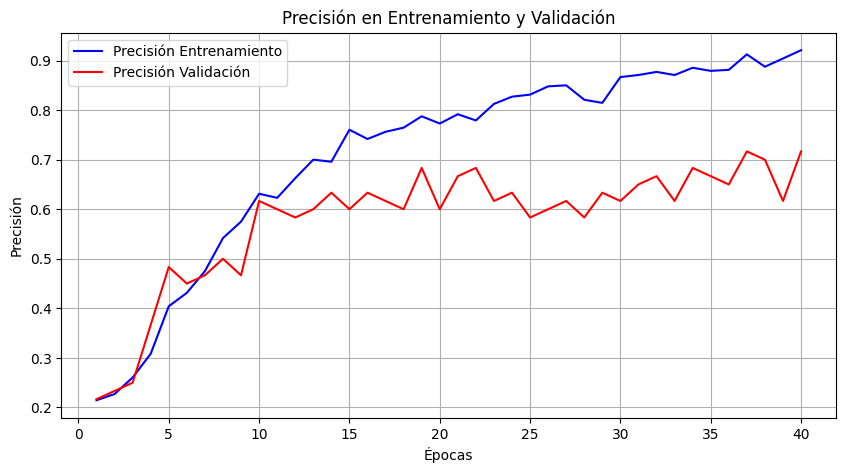

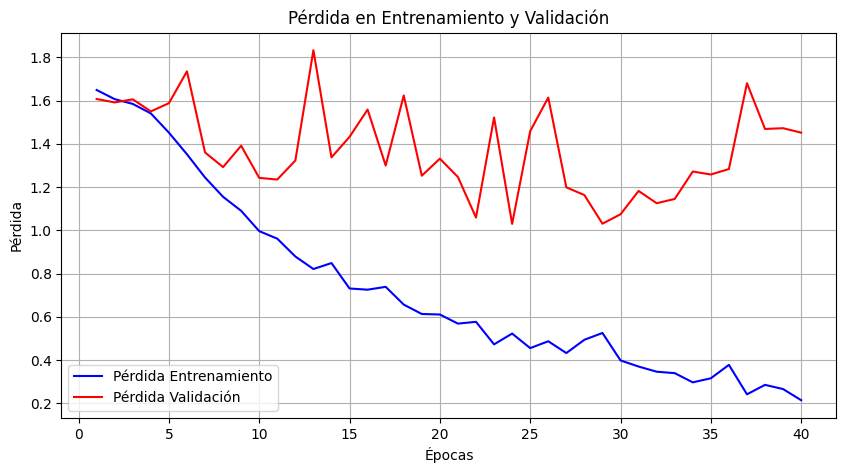

In [3]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=40
)

# Guardamos el historial
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# ---- Gráfica de Precisión ----
plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, 'b-', label='Precisión Entrenamiento')
plt.plot(epochs, val_acc, 'r-', label='Precisión Validación')
plt.title('Precisión en Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.show()

# ---- Gráfica de Pérdida ----
plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, 'b-', label='Pérdida Entrenamiento')
plt.plot(epochs, val_loss, 'r-', label='Pérdida Validación')
plt.title('Pérdida en Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# ==========================
# 4. Evaluación del modelo
# ==========================
test_loss, test_acc = model.evaluate(test_dataset, verbose=2)
print(f"\n Precisión en test: {test_acc*100:.2f}%")



4/4 - 0s - 4ms/step - accuracy: 0.7167 - loss: 1.4514

 Precisión en test: 71.67%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


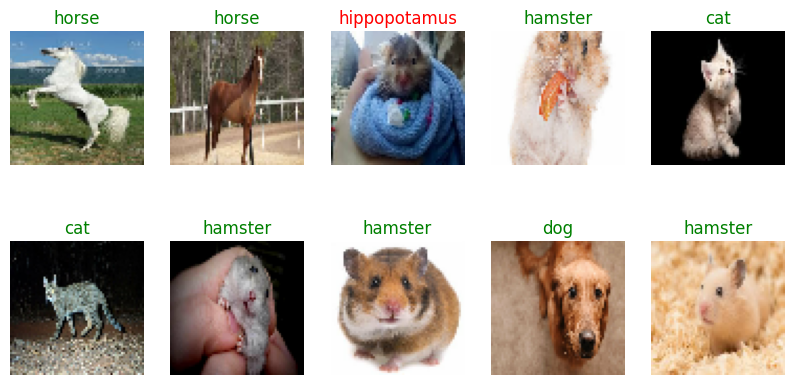

In [11]:
# ==========================
# 5. Predicciones
# ==========================
for images, labels in test_dataset.take(1):
    predictions = model.predict(images)
    pred_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow((images[i].numpy() * 255).astype("uint8"))
        color = 'green' if pred_labels[i] == labels[i].numpy() else 'red'
        plt.title(f"{class_names[pred_labels[i]]}", color=color)
        plt.axis('off')
    plt.show()
